In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle

# load the saved model
with open('../model/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

# load processed data
df = pd.read_csv('../data/processed/processed_data.csv')

# separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# use same test split as before
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Model loaded successfully!")
print("Test data shape:", X_test.shape)

Model loaded successfully!
Test data shape: (56962, 31)


In [2]:
# create SHAP explainer for our XGBoost model
# TreeExplainer is specifically designed for tree based models

explainer = shap.TreeExplainer(model)

# calculate SHAP values for test data
# this tells us how much each feature contributed
# to each prediction in test data

print("Calculating SHAP values...")
shap_values = explainer.shap_values(X_test)

print("Done!")
print("SHAP values shape:", shap_values.shape)

Calculating SHAP values...
Done!
SHAP values shape: (56962, 31)


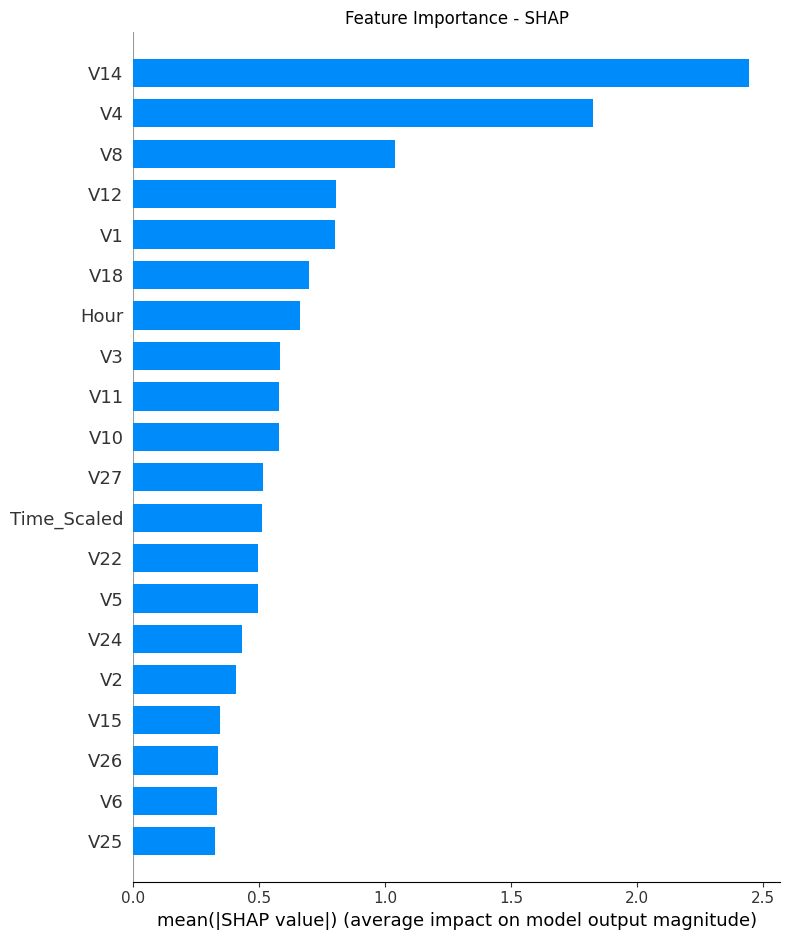

Top 5 most important features:


In [5]:
# summary plot shows which features are most important overall
# red dots  = high feature value pushing toward fraud
# blue dots = low feature value pushing toward legit
# x axis    = SHAP value (how much it affects prediction)
# y axis    = features ranked by importance

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance - SHAP')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top 5 most important features:")
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': abs(shap_values).mean(axis=0)
})
print("shap_importance")